# 3.4

In [2]:
import numpy as np
np.set_printoptions(precision=4)

In [3]:
X = np.array([
    [0.2, 3.1, 1],
    [1.0, 3.0, 1],
    [-0.2, 1.2, 1],
    [1.0, 1.1, 1]
])

y = np.array([1, 1, 0, 0])

w0 = np.array([-1, 1, 0])

In [4]:
def sigmoid(X, w):
    return 1 / (1 + np.exp(-(X @ w)))

def gradient(X, y, w):
    return -X.T @ (y - sigmoid(X, w))

def hessian(X, s):
    return X.T @ np.diag(s * (1 - s)) @ X

def newton_update(X, y, w):
    s = sigmoid(X, w)
    grad = gradient(X, y, w)
    hess = hessian(X, s)
    
    new_w = w - np.linalg.inv(hess) @ grad
    return new_w, s

In [5]:
w1, s0 = newton_update(X, y, w0)
print(f's0: {s0}\nw1: {w1}')

s0: [0.9478 0.8808 0.8022 0.525 ]
w1: [ 1.3247  3.0499 -6.8291]


In [6]:
w2, s1 = newton_update(X, y, w1)
print(f's1: {s1}\nw2: {w2}')

s1: [0.9474 0.9746 0.0312 0.1044]
w2: [ 1.366   4.1575 -9.1996]


# 6.1

In [7]:
import matplotlib.pyplot as plt

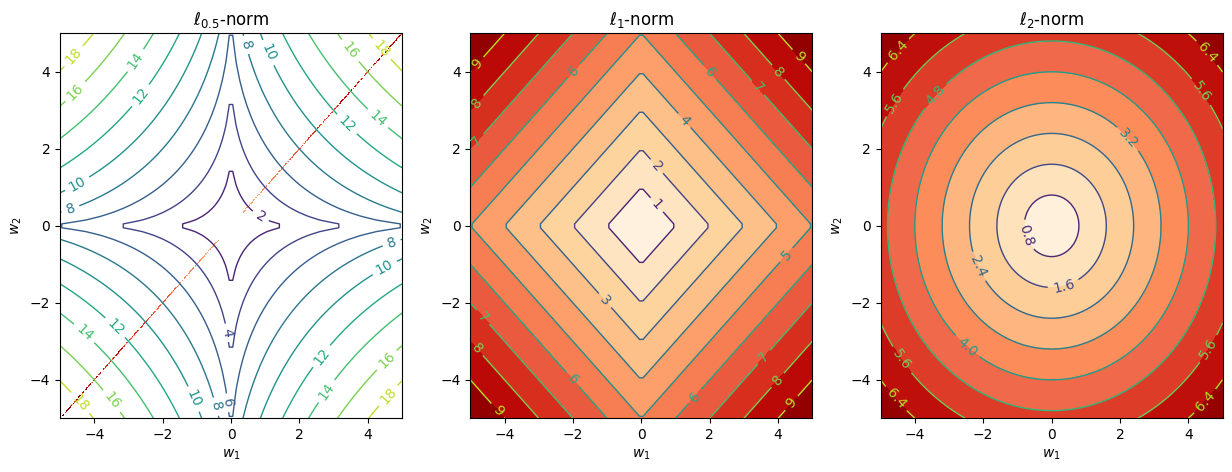

In [18]:
def lp_norm(w1, w2, p):
    return (np.abs(w1)**p + np.abs(w2)**p)**(1/p)

w1, w2 = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))

norms = [0.5, 1, 2]

fig = plt.figure(figsize=(15, 5))

z = lp_norm(w1, w2, 0.5)
plt1 = fig.add_subplot(1, 3, 1)
plt1.contourf(w1, w1, z, 10, cmap='OrRd')
plt1_contour = plt1.contour(w1, w2, z, 10, linewidths=1)
plt.clabel(plt1_contour)
plt1.set_title("$\ell_{0.5}$-norm")
plt1.set_xlabel('$w_1$')
plt1.set_ylabel('$w_2$')

z = lp_norm(w1, w2, 1)
plt2 = fig.add_subplot(1, 3, 2)
plt2.contourf(w1, w2, z, 10, cmap='OrRd')
plt2_contour = plt2.contour(w1, w2, z, 10, linewidths=1)
plt.clabel(plt2_contour)
plt2.set_title("$\ell_{1}$-norm")
plt2.set_xlabel('$w_1$')
plt2.set_ylabel('$w_2$')

z = lp_norm(w1, w2, 2)
plt3 = fig.add_subplot(1, 3, 3)
plt3.contourf(w1, w2, z, 10, cmap='OrRd')
plt3_contour = plt3.contour(w1, w2, z, 10, linewidths=1)
plt.clabel(plt3_contour)
plt3.set_title("$\ell_{2}$-norm")
plt3.set_xlabel('$w_1$')
plt3.set_ylabel('$w_2$')

plt.show();